# FINAL RESULTS — benchmarks/p231 (kMate filt2 + ω=1/m_b global)

Headline benchmark on the **full 231-founder heterogeneous panel** (v3qc+arch3 lineage, random crossovers @ 4 cM/Mb, cn_full rebuilt from arch3). Front-runner method (inv_mb global). Each row = one regime; each column = one cn_var arm (atomized: 7.46M per-base SNP-level | raw: 2.62M SNP+indel+SV). Three panels at increasing missingness tolerance. Record-index join (multiallelic-safe). Memory-streamed: each (regime, cn_var) cell loads its data, plots, then frees.

In [1]:
import sys as _sys
_sys.path.insert(0, "/global/scratch/users/tbellg/kmate/benchmarks")
from _accuracy_panel import scatter_density  # canonical shared aesthetic

import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt, gc
from matplotlib.colors import LogNorm
from pathlib import Path
ROOT=Path("/global/scratch/users/tbellg/kmate/benchmarks/p231")
RES=ROOT/"results"; SIMS=ROOT/"sims"; PLOTS=RES/"plots"; PLOTS.mkdir(parents=True,exist_ok=True)
GREY="#888888"; F=231
REGIMES=["n231_g0","n50_g0","n231_g1","n50_g1","n50_g3","n50_g3_dom500"]
CNVARS=["atomized","raw"]
CN_LABEL={"atomized":"arch3 atomized (SNP-level)","raw":"arch3 raw (SNP+indel+SV)"}
def subdir(reg):
    if reg=="n50_g3_dom500": return "cov10_n50_g3_s42_hotspots_dom500_p231_chr1"
    n,g=reg.split("_g"); return f"cov10_{n}_g{g}_s42_hotspots_p231_chr1"

def load_cell(reg,cv):
    """Load ONE (regime, cnvar) slice. Returns (truth, est, missing_frac) np arrays. Frees source TSVs."""
    tp=SIMS/subdir(reg)/f"recomb_truth_{cv}.tsv.gz"
    ep=RES/f"kmate_global_filt2mb_{cv}"/reg/f"p231_filt2mb_{cv}_{reg}_cov10_s42.tsv"
    tr=pd.read_csv(tp,sep="\t",usecols=["truth_af"])
    es=pd.read_csv(ep,sep="\t",usecols=["alt_freq","n_called"])
    if len(tr)!=len(es): raise RuntimeError(f"len mismatch {reg} {cv}")
    truth=tr["truth_af"].values.astype(np.float32)
    est=es["alt_freq"].values.astype(np.float32)
    miss=((F-es["n_called"].values)/F).astype(np.float32)
    del tr, es; gc.collect()
    return truth, est, miss

def regime_cnvar_panel(miss_thr, suptitle, filename):
    """Build a 6x2 panel by loading each (regime, cnvar) slice on demand and filtering by miss_frac<=miss_thr."""
    CELL=4.0
    fig,axes=plt.subplots(len(REGIMES),len(CNVARS),
                          figsize=(CELL*len(CNVARS)+1,CELL*len(REGIMES)+0.5),
                          sharex=True,sharey=True)
    last_sm=None
    for i,reg in enumerate(REGIMES):
        for j,cv in enumerate(CNVARS):
            ax=axes[i,j] if len(REGIMES)>1 else axes[j]
            truth, est, miss = load_cell(reg, cv)
            sel = miss <= miss_thr
            sm=scatter_density(ax, truth[sel], est[sel],
                               title=f"{CN_LABEL[cv]}  ·  {reg}")
            if sm is not None: last_sm=sm
            if j==0: ax.set_ylabel("Estimated AF")
            if i==len(REGIMES)-1: ax.set_xlabel("True AF")
            del truth, est, miss; gc.collect()
    fig.subplots_adjust(bottom=0.06,top=0.96,hspace=0.30,wspace=0.10)
    cax=fig.add_axes([0.25,0.025,0.50,0.008])
    if last_sm is not None:
        cb=fig.colorbar(last_sm,cax=cax,orientation="horizontal",label="Local density (log count of records)")
        cb.outline.set_edgecolor(GREY); cb.ax.xaxis.set_tick_params(color=GREY,labelcolor=GREY); cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(suptitle,y=0.985,fontsize=11,color=GREY)
    out=PLOTS/filename
    plt.savefig(out,dpi=130,bbox_inches="tight"); plt.show(); plt.close(fig); gc.collect()
    print(f"saved: plots/{filename}")
print("helpers + REGIMES/CNVARS ready")

helpers + REGIMES/CNVARS ready


In [2]:
# --- compact 3x2 (generation x pool-config) grid, raw arm only ---
GRID=[["n231_g0","n50_g0"],["n231_g1","n50_g1"],["n50_g3","n50_g3_dom500"]]
def regime_grid_panel(miss_thr, suptitle, filename, cv="raw"):
    # 3 rows = generations g0/g1/g3; 2 cols = pool config
    # (rows 1-2: N=231 | N=50; bottom row: N=50 | N=50 dom500). Single data arm (raw).
    CELL=4.0
    fig,axes=plt.subplots(len(GRID),2,figsize=(CELL*2+1,CELL*len(GRID)+0.5),sharex=True,sharey=True)
    last_sm=None
    for i,row in enumerate(GRID):
        for j,reg in enumerate(row):
            ax=axes[i,j]
            truth,est,miss=load_cell(reg,cv)
            sel=miss<=miss_thr
            sm=scatter_density(ax,truth[sel],est[sel],title=reg)
            if sm is not None: last_sm=sm
            if j==0: ax.set_ylabel("Estimated AF")
            if i==len(GRID)-1: ax.set_xlabel("True AF")
            del truth,est,miss; gc.collect()
    fig.subplots_adjust(bottom=0.07,top=0.95,hspace=0.30,wspace=0.10)
    cax=fig.add_axes([0.25,0.03,0.50,0.01])
    if last_sm is not None:
        cb=fig.colorbar(last_sm,cax=cax,orientation="horizontal",label="Local density (log count of records)")
        cb.outline.set_edgecolor(GREY); cb.ax.xaxis.set_tick_params(color=GREY,labelcolor=GREY); cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(suptitle,y=0.985,fontsize=11,color=GREY)
    plt.savefig(PLOTS/filename,dpi=130,bbox_inches="tight"); plt.show(); plt.close(fig); gc.collect()
    print(f"saved: plots/{filename}")
print("3x2 grid panel ready")

3x2 grid panel ready


## Panel 1 — RAW results (no missingness filter, all records)

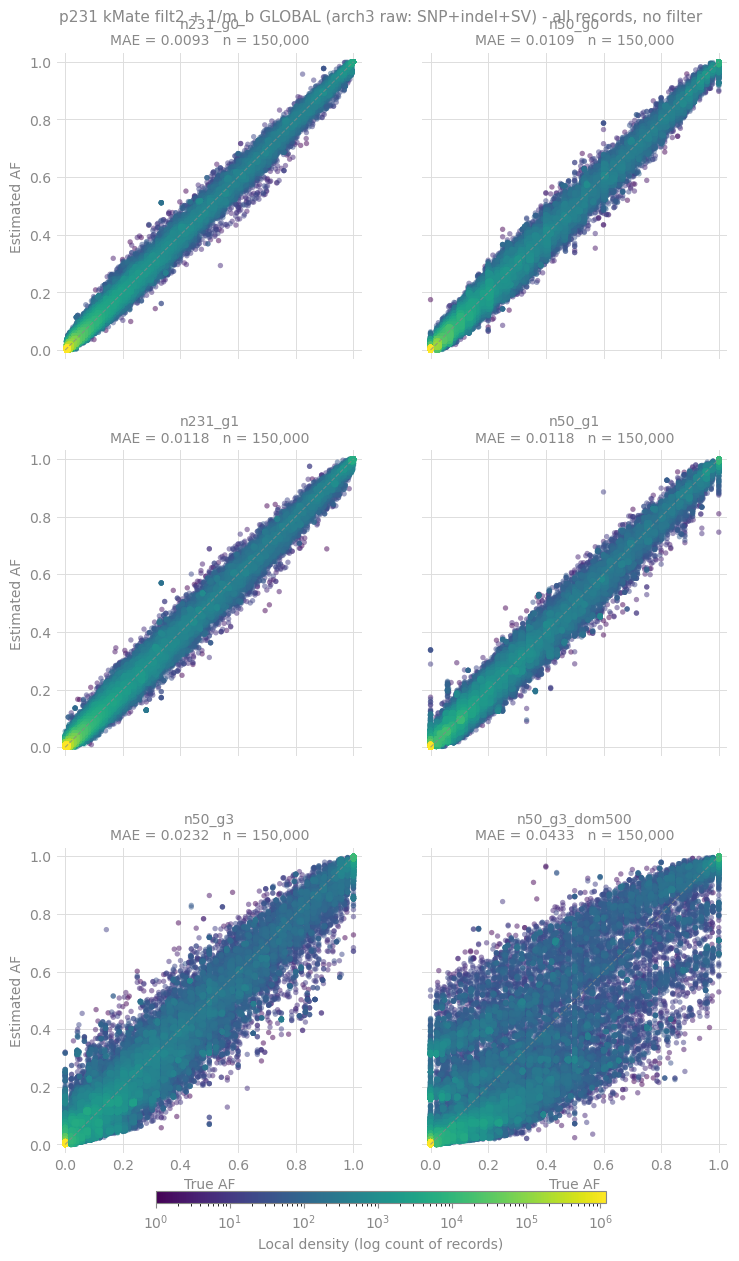

saved: plots/panel_p231_no_filter.png


In [3]:
regime_grid_panel(miss_thr=2.0,
    suptitle="p231 kMate filt2 + 1/m_b GLOBAL (arch3 raw: SNP+indel+SV) - all records, no filter",
    filename="panel_p231_no_filter.png")

## Panel 2 — missingness filter: missing_frac ≤ 0.50

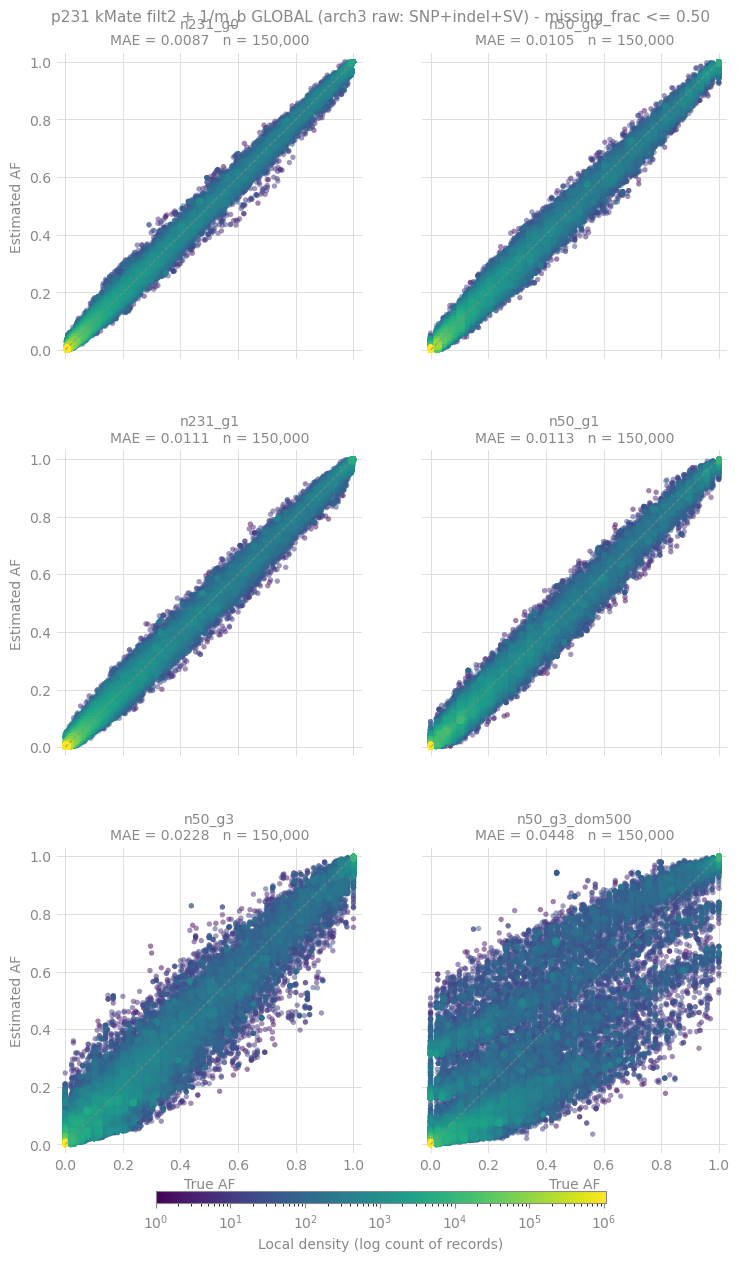

saved: plots/panel_p231_miss50.png


In [4]:
regime_grid_panel(miss_thr=0.50,
    suptitle="p231 kMate filt2 + 1/m_b GLOBAL (arch3 raw: SNP+indel+SV) - missing_frac <= 0.50",
    filename="panel_p231_miss50.png")

## Summary table (MAE / RMSE / outlier per regime × cn_var, all filters)

In [5]:
import math
out=[]
for reg in REGIMES:
    for cv in CNVARS:
        truth, est, miss = load_cell(reg, cv)
        for thr,lab in [(2.0,"no filter"),(0.90,"miss<=0.90"),(0.50,"miss<=0.50")]:
            sel=(miss<=thr)&np.isfinite(truth)&np.isfinite(est)
            t=truth[sel]; e=est[sel]; keep=(t>0)|(e>0); t=t[keep]; e=e[keep]
            if len(t)==0: continue
            d=e-t
            out.append(dict(regime=reg,cnvar=cv,filter=lab,n=len(t),
                            MAE=float(np.abs(d).mean()),
                            RMSE=float(math.sqrt(np.mean(d**2))),
                            outlier=float(np.mean(np.abs(d)>0.10))))
        del truth, est, miss; gc.collect()
summ=pd.DataFrame(out)
pd.set_option("display.width",240,"display.max_columns",30,"display.max_rows",200)
summ.round(5)

,regime,cnvar,filter,n,MAE,RMSE,outlier
0,n231_g0,atomized,no filter,6356634,0.01081,0.01845,0.00287
1,n231_g0,atomized,miss<=0.90,6338115,0.01043,0.01640,0.00056
2,n231_g0,atomized,miss<=0.50,4419912,0.00851,0.01377,0.00037
3,n231_g0,raw,no filter,2155996,0.00923,0.01557,0.00107
4,n231_g0,raw,miss<=0.90,2155259,0.00921,0.01545,0.00096
5,n231_g0,raw,miss<=0.50,1952596,0.00873,0.01473,0.00080
6,n50_g0,atomized,no filter,6340645,0.01202,0.02066,0.00247
7,n50_g0,atomized,miss<=0.90,6322130,0.01188,0.02039,0.00244
8,n50_g0,atomized,miss<=0.50,4403930,0.00961,0.01637,0.00073
9,n50_g0,raw,no filter,2137422,0.01093,0.01897,0.00197
